# Procesos MA

**Idea.** Imaginemos que buscamos conocer el precio de un *stock* $X_{t}$ al tiempo $t>0$. Sin embargo, **no** conocemos cómo fue la distribución del precio en los dos días pasados.  

Entonces, 
$$X_{t}= Z_{t} + 0.7 Z_{t-1} +0.2 Z_{t-2}$$
Aquí, $Z_{t}\sim N(0,1)$.

Este es un proceso de tipo MA$(2)$.

## Simulación

Algoritmo:
- generar ruido blanco $(10000)$.
- introducir a $X_{t}$.
- Loop: Generar a $X_{t}$ para cada ruido blanco.
- Le damos estructura de serie de tiempo con la función ´ts´. 
- Graficar la serie de tiempo.
- Graficar el ACF y concluir.

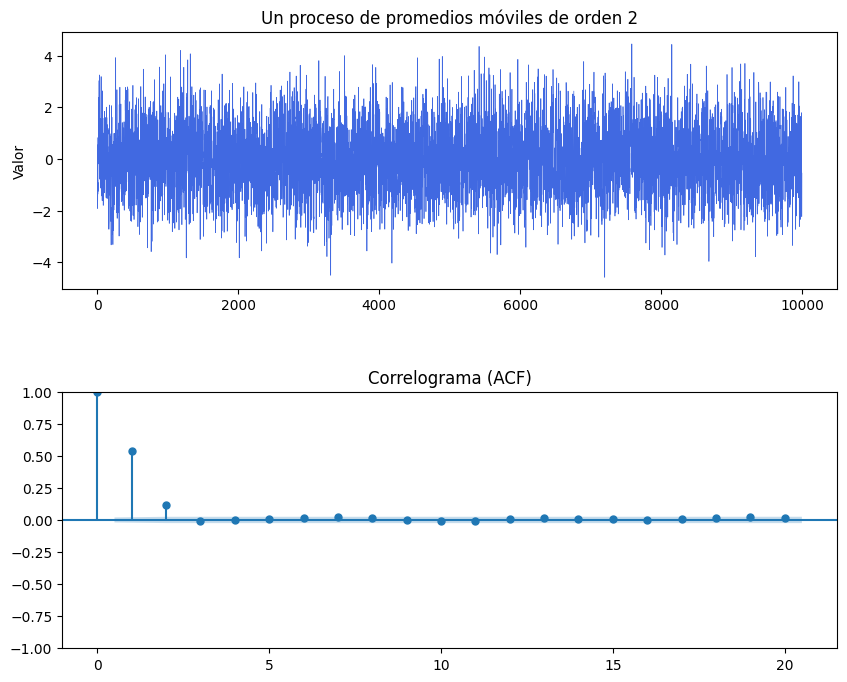

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# 1. Generar ruido blanco (rnorm en R)
n = 10000
noise = np.random.normal(0, 1, n)

# 2. Simulación del proceso MA(2)
# X_t = epsilon_t + 0.7*epsilon_{t-1} + 0.2*epsilon_{t-2}
ma_2 = np.zeros(n)
for t in range(2, n):
    ma_2[t] = noise[t] + 0.7 * noise[t-1] + 0.2 * noise[t-2]

# 3. Quitar los primeros valores (donde no hay rezagos suficientes)
proceso_promedios_moviles = ma_2[2:]

# 4. Visualización (par(mfrow=c(2,1)) en R)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plt.subplots_adjust(hspace=0.4)

# Gráfico de la serie
ax1.plot(proceso_promedios_moviles, color='royalblue', linewidth=0.5)
ax1.set_title("Un proceso de promedios móviles de orden 2")
ax1.set_ylabel("Valor")

# Correlograma (ACF)
plot_acf(proceso_promedios_moviles, ax=ax2, lags=20, title="Correlograma (ACF)")

plt.show()


**Ejercicio.** Generar un proceso MA de orden 3. 

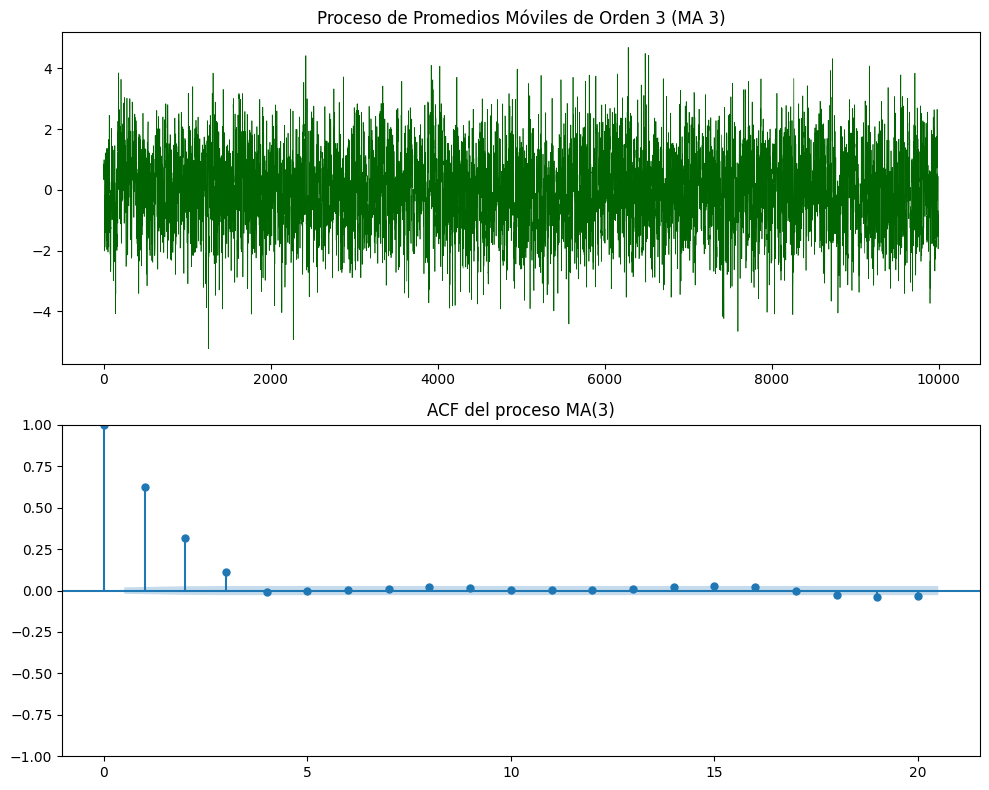

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# 1. Configuración
n = 10000
noise = np.random.normal(0, 1, n)
ma_3 = np.zeros(n)

# 2. Simulación MA(3): X_t = e_t + 0.7*e_{t-1} + 0.4*e_{t-2} + 0.2*e_{t-3}
for t in range(3, n):
    ma_3[t] = noise[t] + 0.7*noise[t-1] + 0.4*noise[t-2] + 0.2*noise[t-3]

# 3. Visualización
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(ma_3[3:], color='darkgreen', lw=0.5)
ax1.set_title("Proceso de Promedios Móviles de Orden 3 (MA 3)")

# El ACF debe mostrar 3 barras significativas antes de caer a cero
plot_acf(ma_3[3:], ax=ax2, lags=20, title="ACF del proceso MA(3)")

plt.tight_layout()
plt.show()
